In [1]:
import sys
sys.path.append("../")

import numpy as np

from mrfsim.epg import *
from mrfsim.mrf_dict import *
from mrfsim.utils import *

### MRF Sequence

In [2]:
# Pseudo-random flip-angle and rep time patterns
fa_pattern = jiang_random_alphas()
tr_pattern = jiang_random_trs()

# Fixed echo time and inversion time
te, ti = 2, 18

# Initialize sequence
sequence = MRFFISPSequence(fa_pattern=fa_pattern, tr_pattern=tr_pattern, te=te, ti=ti)

### Simulate 3 tissues and visualize their response

1000 torch.Size([3, 1000])


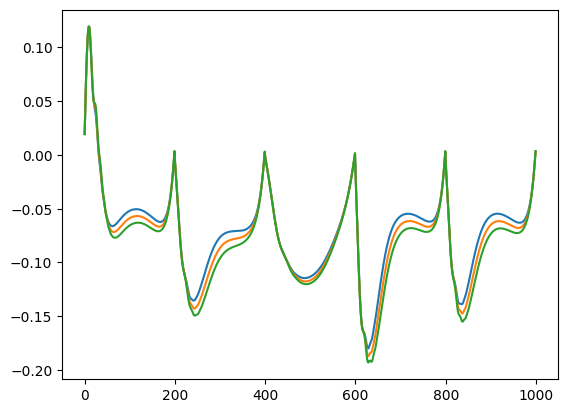

1000 torch.Size([3, 1000])


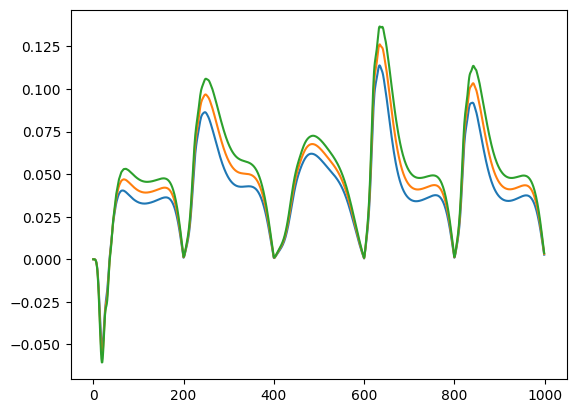

In [3]:
# Create EPG object
epg = EPG(sequence, device='cpu')

# Define 3 tissue types
t1_list = torch.tensor([800, 800, 800])
t2_list = torch.tensor([60, 70, 80])

# Do simulation
epg.simulate(t1_list=t1_list, t2_list=t2_list)
echoes_batch = epg.find_echoes().cpu()
print(len(fa_pattern), echoes_batch.shape)
# print(echoes_batch[torch.abs(echoes_batch) < 5*EPS])

# Visualize signals
for i in range(t1_list.shape[0]):    
    plt.plot(echoes_batch[i].imag) # Time point vs. signal intensity
plt.show()

echoes_batch = epg.find_echoes2().cpu()
print(len(fa_pattern), echoes_batch.shape)
# print(echoes_batch[torch.abs(echoes_batch) < 5*EPS])

# Visualize signals
for i in range(t1_list.shape[0]):    
    plt.plot(echoes_batch[i].imag) # Time point vs. signal intensity
plt.show()

### MRF Dictionary

In [4]:
# Generate parameter grid
param_list = sample_t1t2_parameter_space_with_const_rel_grid(t1_range=[10, 5000], t2_range=[6, 3000], t1_rel_step=0.1, t2_rel_step=0.1)
param_list = {key: torch.tensor(pl) for key, pl in param_list.items()}
print(param_list['t1'].shape)
# print(param_list['t1'])
# print(param_list['t2'])


torch.Size([2754])


Computing dictionary ...


100%|██████████| 2/2 [00:07<00:00,  3.83s/it]

Done



C:\Users\csrao\AppData\Local\Temp\ipykernel_12660\62281956.py:8: DeprecationWarning: __array_wrap__ must accept context and return_scalar arguments (positionally) in the future. (Deprecated NumPy 2.0)
  plt.plot(np.abs(mrfdict.fingerprints[i, :]))


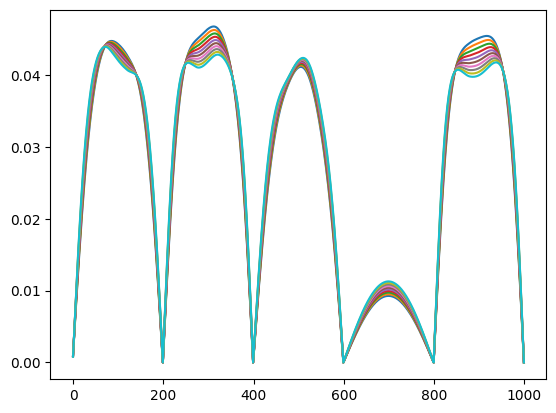

In [9]:
# Dictionary computation on GPU
mrfdict = MRFDictionary(sequence, param_list, device='cuda')
mrfdict.compute(batch_size=2048)
mrfdict.fingerprints.shape

# Visualize 10 fingerprints
for i in range(10):
    plt.plot(np.abs(mrfdict.fingerprints[i, :]))
plt.show()

Computing SVD ...
Done
torch.Size([1000, 10])


C:\Users\csrao\AppData\Local\Temp\ipykernel_12660\4114292689.py:9: DeprecationWarning: __array_wrap__ must accept context and return_scalar arguments (positionally) in the future. (Deprecated NumPy 2.0)
  plt.plot(np.abs(mrfdict.compressed_fingerprints[i, :]))


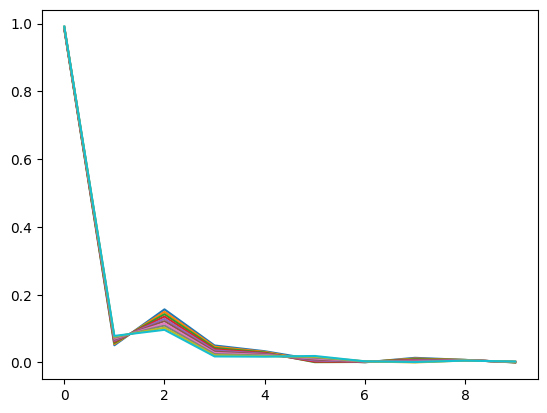

In [6]:
# SVD compression
mrfdict.svd_compress(num_coeffs=10)
mrfdict.compressed_fingerprints.shape
print(mrfdict.compression_matrix.shape)

# Visualize 10 fingerprints
compressed_fignerprints = mrfdict.compressed_fingerprints
for i in range(10):
    plt.plot(np.abs(mrfdict.compressed_fingerprints[i, :]))
plt.show()

In [7]:
# Dictionary matching

signals = mrfdict.fingerprints[0:500:100] * mrfdict.fingerprint_norm_factors[0:500:100]
proton_densities = torch.tensor([0.5, 0.7, 0.2, 0.3, 0.1]).unsqueeze(1)
signals = signals * proton_densities
print("True T1:", mrfdict.param_lists['t1'][0:500:100])
print("True T2:", mrfdict.param_lists['t2'][0:500:100])
print("True PD:", proton_densities.squeeze(), "\n")

best_params = mrfdict.match_signals(signals, compress_signals=False)
print(best_params)

True T1: tensor([  10,  103, 1563,   36,  605])
True T2: tensor([ 6,  7,  8, 10, 11])
True PD: tensor([0.5000, 0.7000, 0.2000, 0.3000, 0.1000]) 

Matching ...


100%|██████████| 6/6 [00:00<00:00, 1999.99it/s]

Done
{'t1': tensor([  10,  103, 1563,   36,  605]), 't2': tensor([ 7,  7,  8, 10, 11]), 'm0': tensor([0.4772, 0.7000, 0.2000, 0.3000, 0.1000])}
